In [1]:
library(tidyverse)
library(readr)      
library(dplyr)
library(stringr)
library(janitor)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘janitor’


The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test




In [ ]:
data <- read_csv("/Volumes/NGS/Rproject/Clinical_trail_Covid19_studies/data/ctg-studies.csv") %>%
  janitor::clean_names() %>%
  mutate(
    conditions = str_to_lower(conditions),
    phases     = str_to_upper(phases),
    sex        = str_to_title(sex),
    study_type = str_to_title(study_type),
    sex = factor(sex, 
                 levels = c("All","Male","Female"),
                 labels = c("All","Male","Female"))
  )  %>% 
  filter(str_detect(conditions, "covid|sars")) %>%
  dplyr::filter(study_type == "Interventional") 
 

### Phase distributation analysis base on number of Trials ###

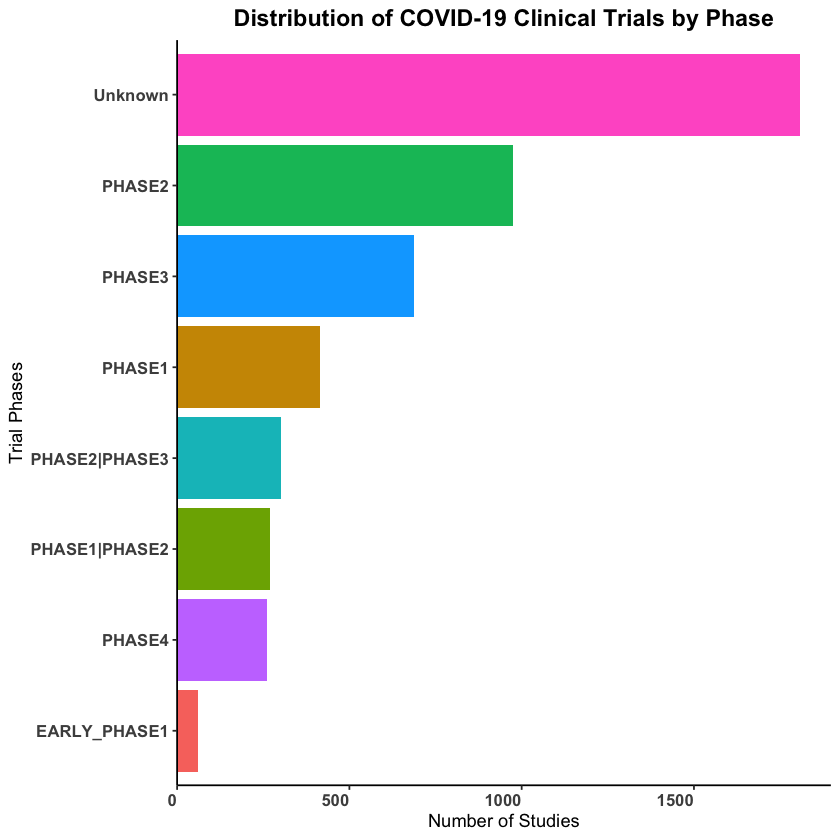

In [ ]:
data %>% 
  mutate(
    phases = str_to_upper(phases),
    phases = tidyr::replace_na(phases, "Unknown")
  ) %>%
  group_by(phases) %>%
  summarise(n_studies = n(), .groups = "drop") %>%
  arrange(desc(n_studies)) %>% 
  
  ggplot(aes(x = n_studies,
             y = reorder(phases, n_studies),
             fill = phases)) +
  geom_col() +
  scale_x_continuous(expand = expansion(mult = c(0, 0.05))) +
  labs(x = "Phases", y = "Number of Studies", title = "Distribution of COVID-19 Clinical Trials by Phase") +
    labs(y = "Trial Phases", 
    x = "Number of Studies", 
    title = "Distribution of COVID-19 Clinical Trials by Phase") +
    theme_classic() +
    theme(
      legend.position = "none",
      axis.text.x = element_text(angle = 0, hjust = 1, face = "bold", size = 10),
          axis.text.y = element_text(size = 10, face = "bold"),
          plot.title = element_text(size = 14, face = "bold", hjust = 0.5)) 
     
ggsave("/Volumes/NGS/Rproject/Clinical_trail_Covid19_studies/visuals/phase_distribution.png", width = 8, height = 6)

#### Number of countris involved in clinical trials ####

In [69]:
library(dplyr)
library(stringr)
library(tidyr)

country_data <- data %>%
  filter(!is.na(locations)) %>%
  separate_rows(locations, sep = ";") %>%   # split multiple locations
  mutate(
    locations = str_trim(locations),
    country = str_extract(locations, "[^,]+$"),  # 🔥 take last part
    country = str_trim(country)
  )
head(country_data,2)

nct_number,study_title,study_url,study_status,brief_summary,study_results,conditions,interventions,sponsor,collaborators,sex,age,phases,study_type,start_date,primary_completion_date,completion_date,results_first_posted,locations,country
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<date>,<chr>,<chr>
NCT05886790,A Clinical Trial on Booster Immunization of Two COVID-19 Vaccines Constructed From Different Technical Routes,https://clinicaltrials.gov/study/NCT05886790,UNKNOWN,"This is an open-label, randomized, parallel-controlled clinical trial conducted in people aged 18 years and older to evaluate the immunogenicity and safety of two SARS-CoV-2 bivalent vaccines constructed by adenovirus type 5-based or mRNA-based technics.",NO,covid-19,BIOLOGICAL: Prototype and Omicron BA.4/5 Bivalent Recombinant COVID-19 Vaccine(Adenovirus Type 5 Vector) For Inhalation|BIOLOGICAL: Bivalent COVID-19 mRNA Vaccine|BIOLOGICAL: Recombinant COVID-19 Vaccine (Adenovirus Type 5 Vector) For Inhalation,Zhongnan Hospital,"Institute of Biotechnology, Academy of Military Medical Sciences, PLA of China",All,"ADULT, OLDER_ADULT",NA,Interventional,2023-05-30,2023-12-31,2024-05-29,NA,"Zhongnan Hospital of Wuhan University, Wuhan, Hubei, 430000, China",China
NCT04800224,Brazilian Green Propolis Extract (EPP-AF) as an Adjunct Treatment for Hospitalized COVID-19 Patients (BeeCovid2),https://clinicaltrials.gov/study/NCT04800224,COMPLETED,"Severe acute respiratory syndrome coronavirus 2 (SARS-CoV-2) promotes challenging immune and inflammatory phenomena. Though various therapeutic possibilities have been tested against coronavirus disease 2019 (COVID-19), the most adequate treatment has not yet been established. Among candidate adjunct treatment options, propolis, produced by honey bees from bioactive plant exudates, has shown potential against viral targets and has demonstrated immunoregulatory properties.",NO,covid19|inflammation,DRUG: Standardized Brazilian Green Propolis Extract|DRUG: Placebo,D'Or Institute for Research and Education,Apis Flora Industrial e Comercial Ltda,All,"ADULT, OLDER_ADULT",PHASE2|PHASE3,Interventional,2021-04-12,2021-07-30,2021-07-30,NA,"Hospital Sao Rafael, Salvador, Estado de Bahia, 41820340, Brazil",Brazil


In [61]:
country_summary <- country_data %>%
  mutate(
    country = case_when(
      country %in% c("United States", "USA") ~ "USA",
      country %in% c("United Kingdom") ~ "UK",
      TRUE ~ country
    )
  )%>%
  count(country, sort = TRUE)
country_summary

country,n
<chr>,<int>
USA,1184
China,318
France,234
Spain,209
UK,171
Brazil,169
Canada,157
Turkey (Türkiye),148
Egypt,124


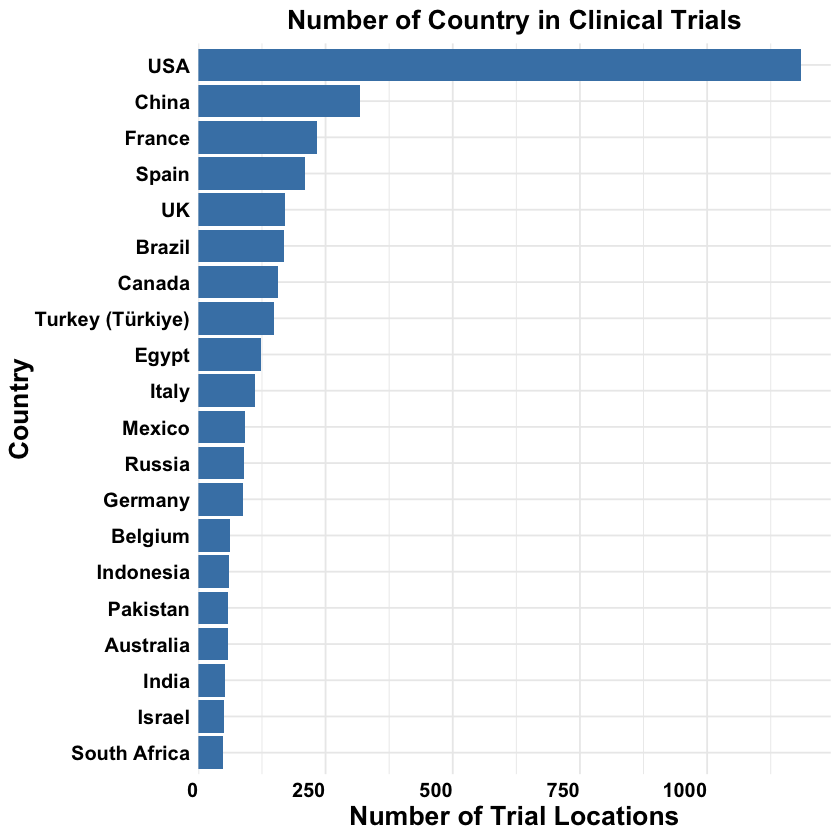

In [80]:
ggplot(country_summary[1:20,],
       aes(x = reorder(country, n), y = n)) +
  geom_col(fill = "steelblue") +
  scale_y_continuous(expand = expansion(mult = c(0, 0.05))) +
  coord_flip() +
  labs(x = "Country", 
  y = "Number of Trial Locations",
     title = "Number of Country in Clinical Trials") +
    theme_minimal() +
    theme(
      legend.position = "none",
      axis.title = element_text(size = 16, face = "bold", colour = "black"),
      axis.text.x = element_text(angle = 0, hjust = 1, face = "bold", size = 12, colour = "black"),
      axis.text.y = element_text(size = 12, face = "bold",colour = "black"),
      plot.title = element_text(size = 16, face = "bold", hjust = 0.5,colour = "black"))
ggsave("/Volumes/NGS/Rproject/Clinical_trail_Covid19_studies/visuals/country_distribution.png", width = 8, height = 6)
